# NB05B — EBM Interpretability Benchmark (M2.5)

**Purpose:** Introduce the Explainable Boosting Machine (EBM) as model M2.5 — a
natively interpretable non-linear model positioned between the Random Forest (M2)
and the XGBoost+FinBERT model (M3) in the interpretability–accuracy framework.

**This notebook is a standalone extension of NB05A.**
It reads pre-built datasets and feature lists saved by NB05A and does not
repeat any data construction. Run NB05A to completion before opening this notebook.

## Model sequence in the dissertation

| Model | Algorithm | Features | Interpretability | Stage |
|-------|-----------|----------|-----------------|-------|
| M1    | Logistic Regression | 19 macro lag1 | Linear — fully transparent | S1 |
| M2    | Random Forest | 41 macro lag1–3 | Post-hoc SHAP only | S1 |
| **M2.5 (EBM)** | **Explainable Boosting Machine** | **41 macro lag1–3** | **Native shape functions** | **S1 + S2** |
| M3    | XGBoost + FinBERT | 61 macro + sentiment | Post-hoc SHAP only | S2 |

## What this notebook produces

1. **OOS metrics** — AUROC, AUPRC, Brier for EBM (Stage 1 and Stage 2)
2. **Shape function plots** — credit growth and term spread risk curves pre-GFC vs GFC
3. **Regime instability evidence** — EBM shape instability directly supports H3
4. **CSV outputs** — OOS predictions appended to stage1/stage2 files for NB06A

## Inputs (must exist before running)
- `data/processed/augmented_analysis/df_macro_augmented.csv`
- `data/processed/augmented_analysis/df_sent_augmented.csv`
- `data/processed/augmented_analysis/M2_features.csv`
- `data/processed/augmented_analysis/oos_predictions_stage1.csv`
- `data/processed/augmented_analysis/oos_predictions_stage2.csv`

## Outputs
- `data/processed/augmented_analysis/oos_predictions_stage1_ebm.csv`
- `data/processed/augmented_analysis/oos_predictions_stage2_ebm.csv`
- `figures/augmented_analysis/ebm_shape_regime_comparison.png`
- `figures/augmented_analysis/ebm_roc_pr_curves.png`
- `figures/augmented_analysis/ebm_feature_importance.png`

---

## Cell 1 — Imports and paths

In [1]:
import os, warnings
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from math import isnan as import_isnan

# Core ML
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.metrics import average_precision_score as _aps
from sklearn.utils import resample

# EBM — this is the key new import
from interpret.glassbox import ExplainableBoostingClassifier

# ── Paths (identical structure to NB05A) ──────────────────────────────────
BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
OUT_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
FIG_DIR = BASE / 'figures' / 'augmented_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET       = 'target_h2'
N_BOOTSTRAP  = 1000

# ── Verify all NB05A outputs exist before proceeding ──────────────────────
required_files = [
    OUT_DIR / 'df_macro_augmented.csv',
    OUT_DIR / 'df_sent_augmented.csv',
    OUT_DIR / 'M2_features.csv',
    OUT_DIR / 'oos_predictions_stage1.csv',
    OUT_DIR / 'oos_predictions_stage2.csv',
]

all_ok = True
for f in required_files:
    exists = f.exists()
    status = '✅' if exists else '❌ MISSING'
    print(f'  {status}  {f.name}')
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError('One or more NB05A outputs are missing. Run NB05A first.')

print()
print('=' * 65)
print(' NB05B — EBM INTERPRETABILITY BENCHMARK')
print('=' * 65)

# Confirm interpret version
import interpret
print(f'interpret version : {interpret.__version__}')
print(f'numpy             : {np.__version__}')
print(f'Random state      : {RANDOM_STATE}')

  ✅  df_macro_augmented.csv
  ✅  df_sent_augmented.csv
  ✅  M2_features.csv
  ✅  oos_predictions_stage1.csv
  ✅  oos_predictions_stage2.csv

 NB05B — EBM INTERPRETABILITY BENCHMARK
interpret version : 0.7.8
numpy             : 2.4.2
Random state      : 42


## Cell 2 — Load NB05A datasets and feature lists

All data construction (lag engineering, demeaning, sentiment merge) was completed
in NB05A. This cell simply reads the saved outputs.

In [2]:
# ── Load datasets ──────────────────────────────────────────────────────────
df_macro = pd.read_csv(OUT_DIR / 'df_macro_augmented.csv')
df_sent  = pd.read_csv(OUT_DIR / 'df_sent_augmented.csv')

# ── Load feature lists ─────────────────────────────────────────────────────
# EBM uses the same 41 macro features as M2 — same data, different algorithm
M2_FEATURES = pd.read_csv(OUT_DIR / 'M2_features.csv', header=None)[0].tolist()
EBM_FEATURES = M2_FEATURES  # explicit alias for clarity in the code below

# ── Load existing OOS predictions (will merge EBM column onto these) ───────
oos_s1 = pd.read_csv(OUT_DIR / 'oos_predictions_stage1.csv')
oos_s2 = pd.read_csv(OUT_DIR / 'oos_predictions_stage2.csv')

# ── Dataset summary ────────────────────────────────────────────────────────
n_crisis_macro  = int(df_macro[TARGET].sum())
base_rate_macro = df_macro[TARGET].mean()
n_crisis_sent   = int(df_sent[TARGET].sum())
base_rate_sent  = df_sent[TARGET].mean()

print('=== DATASETS LOADED FROM NB05A ===')
print()
print(f'Stage 1 — df_macro:')
print(f'  Rows          : {len(df_macro)}')
print(f'  Year range    : {df_macro["year"].min():.0f} – {df_macro["year"].max():.0f}')
print(f'  Crisis events : {n_crisis_macro}  (base rate {100*base_rate_macro:.1f}%)')
print()
print(f'Stage 2 — df_sent:')
print(f'  Rows          : {len(df_sent)}')
print(f'  Year range    : {df_sent["year"].min():.0f} – {df_sent["year"].max():.0f}')
print(f'  Crisis events : {n_crisis_sent}  (base rate {100*base_rate_sent:.1f}%)')
print()
print(f'EBM feature set : {len(EBM_FEATURES)} macro features (identical to M2)')
print()

# Confirm all EBM features exist in both datasets
missing_macro = [f for f in EBM_FEATURES if f not in df_macro.columns]
missing_sent  = [f for f in EBM_FEATURES if f not in df_sent.columns]
if missing_macro or missing_sent:
    raise ValueError(f'Missing features — macro: {missing_macro}  sent: {missing_sent}')
print('✅ All EBM features present in both datasets.')

=== DATASETS LOADED FROM NB05A ===

Stage 1 — df_macro:
  Rows          : 569
  Year range    : 1989 – 2020
  Crisis events : 37  (base rate 6.5%)

Stage 2 — df_sent:
  Rows          : 319
  Year range    : 2003 – 2020
  Crisis events : 26  (base rate 8.2%)

EBM feature set : 41 macro features (identical to M2)

✅ All EBM features present in both datasets.


## Cell 3 — Expanding-window CV function

Identical to NB05A — reproduced here so this notebook is self-contained.
EBM is passed through exactly the same CV loop as M1, M2, and M3.

In [3]:
def expanding_window_cv(df, feature_cols, target_col, model_factory,
                        min_train_years=4, hold_out_years=(2019, 2020)):
    """Expanding-window cross-validation.
    
    Identical implementation to NB05A — ensures EBM metrics are
    directly comparable to M1, M2, and M3 results.
    """
    cv_years   = sorted(y for y in df['year'].unique() if y not in hold_out_years)
    first_eval = cv_years[min_train_years]
    eval_years = [y for y in cv_years if y >= first_eval]
    print(f'  Burn-in: {cv_years[0]:.0f}–{first_eval-1:.0f} | '
          f'Eval: {eval_years[0]:.0f}–{eval_years[-1]:.0f} ({len(eval_years)} folds)')

    oos_idx, oos_prob, fold_records = [], [], []
    fold_auprcs = []

    for yr in eval_years:
        tr = df['year'] < yr
        te = df['year'] == yr
        X_tr, y_tr = df.loc[tr, feature_cols], df.loc[tr, target_col]
        X_te, y_te = df.loc[te, feature_cols], df.loc[te, target_col]
        if y_tr.sum() == 0 or len(X_te) == 0:
            continue

        n_neg_fold = (y_tr == 0).sum()
        n_pos_fold = max((y_tr == 1).sum(), 1)
        fold_spw   = n_neg_fold / n_pos_fold

        mdl = model_factory(fold_spw)
        mdl.fit(X_tr.values, y_tr.values)

        prob = mdl.predict_proba(X_te.values)[:, 1]
        oos_idx.extend(df.index[te].tolist())
        oos_prob.extend(prob.tolist())

        fold_auprc = _aps(y_te, prob) if y_te.sum() > 0 else float('nan')
        if not import_isnan(fold_auprc):
            fold_auprcs.append(fold_auprc)

        fold_records.append({
            'year': int(yr), 'n_train': int(tr.sum()),
            'crises_train': int(y_tr.sum()),
            'n_test': len(y_te), 'crises_test': int(y_te.sum()),
            'fold_spw': round(fold_spw, 2),
            'fold_auprc': round(fold_auprc, 4) if not import_isnan(fold_auprc) else 'n/a'
        })

    y_oos = df.loc[oos_idx, target_col].values
    if fold_auprcs:
        print(f'  Per-fold AUPRC (folds with crisis cases): '
              f'mean={np.mean(fold_auprcs):.4f}  std={np.std(fold_auprcs):.4f}')

    return y_oos, np.array(oos_prob), oos_idx, pd.DataFrame(fold_records)


def bootstrap_metrics(y_true, y_prob, n_boot=N_BOOTSTRAP, seed=RANDOM_STATE):
    """Bootstrap 95% CI for AUROC and AUPRC."""
    rng = np.random.RandomState(seed)
    auroc_scores, auprc_scores = [], []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if len(np.unique(y_true[idx])) < 2:
            continue
        auroc_scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
        auprc_scores.append(average_precision_score(y_true[idx], y_prob[idx]))
    return {
        'auroc_ci': (np.percentile(auroc_scores, 2.5), np.percentile(auroc_scores, 97.5)),
        'auprc_ci': (np.percentile(auprc_scores, 2.5), np.percentile(auprc_scores, 97.5)),
    }

print('CV and bootstrap functions ready.')

CV and bootstrap functions ready.


## Cell 4 — EBM model factory

EBM hyperparameters follow the `interpret` package defaults, which are well-tested
for tabular data of this scale. The `interactions` parameter is set to 5 to allow
EBM to detect non-additive pairwise relationships while remaining interpretable.
Class imbalance is handled via `max_rounds` and the per-fold `class_weight`
equivalent passed through `min_samples_leaf`.

Note: EBM does not use `scale_pos_weight` (that is XGBoost-specific). Instead,
we pass `sample_weight` proportional to the inverse class frequency at fit time.

In [4]:
def ebm_factory(fold_spw=None):
    """EBM model factory for use in expanding_window_cv.
    
    fold_spw is the per-fold negative/positive ratio passed by the CV loop.
    EBM handles class imbalance via sample_weight at fit time (see wrapper below).
    """
    return ExplainableBoostingClassifier(
        max_rounds=5000,           # sufficient for convergence on small panels
        interactions=5,            # allow up to 5 pairwise interaction terms
        learning_rate=0.01,        # conservative — reduces overfitting on thin folds
        min_samples_leaf=2,        # allow fitting on small training sets
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


# EBM.fit() accepts sample_weight — we use this to handle class imbalance
# This wrapper replaces the standard CV loop's direct .fit(X, y) call
class EBMWeighted:
    """Thin wrapper that applies inverse-frequency sample weights at fit time."""

    def __init__(self, fold_spw):
        self.fold_spw = fold_spw  # neg/pos ratio from CV loop
        self._model   = ExplainableBoostingClassifier(
            max_rounds=5000,
            interactions=5,
            learning_rate=0.01,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    def fit(self, X, y):
        # Assign weight fold_spw to positives, 1.0 to negatives
        sample_weight = np.where(y == 1, self.fold_spw, 1.0)
        self._model.fit(X, y, sample_weight=sample_weight)
        return self

    def predict_proba(self, X):
        return self._model.predict_proba(X)

    def get_ebm(self):
        """Return the underlying EBM for shape function extraction."""
        return self._model


def ebm_weighted_factory(fold_spw=None):
    spw = fold_spw if fold_spw is not None else 1.0
    return EBMWeighted(spw)


print('EBM model factory ready.')
print(f'  Algorithm         : ExplainableBoostingClassifier')
print(f'  Interactions      : 5 pairwise terms')
print(f'  Learning rate     : 0.01')
print(f'  Class imbalance   : sample_weight (inverse frequency)')
print(f'  Feature set       : {len(EBM_FEATURES)} macro features (same as M2)')

EBM model factory ready.
  Algorithm         : ExplainableBoostingClassifier
  Interactions      : 5 pairwise terms
  Learning rate     : 0.01
  Class imbalance   : sample_weight (inverse frequency)
  Feature set       : 41 macro features (same as M2)


## Cell 5 — Stage 1: Train EBM on extended macro panel (1988–2020)

EBM as M2.5 on Stage 1 data. Directly comparable to M2 (same features, same CV folds).
This cell may take 3–8 minutes — EBM is slower than RF due to boosting iterations.

In [5]:
print('=== STAGE 1: Training EBM (M2.5) on df_macro (1988–2020) ===')
print(f'Dataset : {len(df_macro)} rows | {n_crisis_macro} target_h2 positives')
print(f'Features: {len(EBM_FEATURES)} (identical to M2)')
print()
print('Training EBM M2.5 (Stage 1) — this may take several minutes...')
print()

y_ebm_s1, prob_ebm_s1, idx_ebm_s1, folds_ebm_s1 = expanding_window_cv(
    df_macro, EBM_FEATURES, TARGET, ebm_weighted_factory
)

auroc_ebm_s1 = roc_auc_score(y_ebm_s1, prob_ebm_s1)
auprc_ebm_s1 = average_precision_score(y_ebm_s1, prob_ebm_s1)
brier_ebm_s1 = brier_score_loss(y_ebm_s1, prob_ebm_s1)
ci_s1        = bootstrap_metrics(y_ebm_s1, prob_ebm_s1)

print()
print('=== EBM M2.5 — Stage 1 Results ===')
print(f'  AUROC : {auroc_ebm_s1:.4f}  '
      f'95% CI [{ci_s1["auroc_ci"][0]:.3f}, {ci_s1["auroc_ci"][1]:.3f}]')
print(f'  AUPRC : {auprc_ebm_s1:.4f}  '
      f'95% CI [{ci_s1["auprc_ci"][0]:.3f}, {ci_s1["auprc_ci"][1]:.3f}]')
print(f'  Brier : {brier_ebm_s1:.4f}')
print(f'  AUPRC lift over base rate ({base_rate_macro:.3f}): '
      f'{auprc_ebm_s1/base_rate_macro:.1f}×')
print()

# Load M2 results from NB05A for immediate comparison
results_nb05a = pd.read_csv(OUT_DIR / 'augmented_model_results.csv')
m2_row = results_nb05a[results_nb05a['Model'].str.contains('M2 Random Forest')].iloc[0]
print(f'  M2 RF (NB05A)    : AUROC={m2_row["AUROC"]:.4f}  AUPRC={m2_row["AUPRC"]:.4f}')
print(f'  EBM M2.5 (this)  : AUROC={auroc_ebm_s1:.4f}  AUPRC={auprc_ebm_s1:.4f}')
print(f'  AUROC delta (EBM − RF): {auroc_ebm_s1 - m2_row["AUROC"]:+.4f}')
print(f'  AUPRC delta (EBM − RF): {auprc_ebm_s1 - m2_row["AUPRC"]:+.4f}')

=== STAGE 1: Training EBM (M2.5) on df_macro (1988–2020) ===
Dataset : 569 rows | 37 target_h2 positives
Features: 41 (identical to M2)

Training EBM M2.5 (Stage 1) — this may take several minutes...

  Burn-in: 1989–1992 | Eval: 1993–2018 (26 folds)
  Per-fold AUPRC (folds with crisis cases): mean=0.6113  std=0.3491

=== EBM M2.5 — Stage 1 Results ===
  AUROC : 0.7528  95% CI [0.649, 0.849]
  AUPRC : 0.2725  95% CI [0.154, 0.470]
  Brier : 0.0637
  AUPRC lift over base rate (0.065): 4.2×

  M2 RF (NB05A)    : AUROC=0.6359  AUPRC=0.2242
  EBM M2.5 (this)  : AUROC=0.7528  AUPRC=0.2725
  AUROC delta (EBM − RF): +0.1170
  AUPRC delta (EBM − RF): +0.0483


## Cell 6 — Stage 2: Train EBM on sentiment overlap period (2003–2020)

EBM as M2.5-matched on Stage 2 data. Uses the same 41 macro features (not sentiment).
This creates a clean three-way Stage 2 comparison:
M2-matched (RF) vs EBM (interpretable) vs M3 (XGBoost + FinBERT).

In [6]:
print('=== STAGE 2: Training EBM (M2.5-matched) on df_sent (2003–2020) ===')
print(f'Dataset : {len(df_sent)} rows | {n_crisis_sent} target_h2 positives')
print(f'Features: {len(EBM_FEATURES)} macro only (no sentiment — interpretability baseline)')
print()
print('Training EBM M2.5-matched (Stage 2) — this may take several minutes...')
print()

y_ebm_s2, prob_ebm_s2, idx_ebm_s2, folds_ebm_s2 = expanding_window_cv(
    df_sent, EBM_FEATURES, TARGET, ebm_weighted_factory
)

auroc_ebm_s2 = roc_auc_score(y_ebm_s2, prob_ebm_s2)
auprc_ebm_s2 = average_precision_score(y_ebm_s2, prob_ebm_s2)
brier_ebm_s2 = brier_score_loss(y_ebm_s2, prob_ebm_s2)
ci_s2        = bootstrap_metrics(y_ebm_s2, prob_ebm_s2)

print()
print('=== EBM M2.5-matched — Stage 2 Results ===')
print(f'  AUROC : {auroc_ebm_s2:.4f}  '
      f'95% CI [{ci_s2["auroc_ci"][0]:.3f}, {ci_s2["auroc_ci"][1]:.3f}]')
print(f'  AUPRC : {auprc_ebm_s2:.4f}  '
      f'95% CI [{ci_s2["auprc_ci"][0]:.3f}, {ci_s2["auprc_ci"][1]:.3f}]')
print(f'  Brier : {brier_ebm_s2:.4f}')
print(f'  AUPRC lift over base rate ({base_rate_sent:.3f}): '
      f'{auprc_ebm_s2/base_rate_sent:.1f}×')
print()

# Load M2-matched and M3 results from NB05A for immediate comparison
m2m_row = results_nb05a[results_nb05a['Model'].str.contains('M2-matched')].iloc[0]
m3_row  = results_nb05a[results_nb05a['Model'].str.contains('M3')].iloc[0]
print('Stage 2 three-way comparison:')
print(f'  M2-matched RF   : AUROC={m2m_row["AUROC"]:.4f}  AUPRC={m2m_row["AUPRC"]:.4f}  (post-hoc SHAP)')
print(f'  EBM M2.5-matched: AUROC={auroc_ebm_s2:.4f}  AUPRC={auprc_ebm_s2:.4f}  (native shapes)')
print(f'  M3 XGB+FinBERT  : AUROC={m3_row["AUROC"]:.4f}  AUPRC={m3_row["AUPRC"]:.4f}  (post-hoc SHAP)')

=== STAGE 2: Training EBM (M2.5-matched) on df_sent (2003–2020) ===
Dataset : 319 rows | 26 target_h2 positives
Features: 41 macro only (no sentiment — interpretability baseline)

Training EBM M2.5-matched (Stage 2) — this may take several minutes...

  Burn-in: 2003–2006 | Eval: 2007–2018 (12 folds)
  Per-fold AUPRC (folds with crisis cases): mean=0.8141  std=0.0000

=== EBM M2.5-matched — Stage 2 Results ===
  AUROC : 0.9599  95% CI [0.927, 0.988]
  AUPRC : 0.5320  95% CI [0.265, 0.827]
  Brier : 0.0672
  AUPRC lift over base rate (0.082): 6.5×

Stage 2 three-way comparison:
  M2-matched RF   : AUROC=0.9385  AUPRC=0.3428  (post-hoc SHAP)
  EBM M2.5-matched: AUROC=0.9599  AUPRC=0.5320  (native shapes)
  M3 XGB+FinBERT  : AUROC=0.9316  AUPRC=0.4110  (post-hoc SHAP)


## Cell 7 — Full combined results table (M1, M2, EBM, M3)

Reproduces the NB05A results table with EBM inserted as M2.5.
This is the table that feeds into the revised Chapter 4, Table 4.1 / 4.2.

In [7]:
print('=' * 95)
print(' FULL MODEL COMPARISON — M1 → M2 → EBM (M2.5) → M3')
print('=' * 95)
print(f' {"Model":<50} {"Stage":>5} {"Events":>7} '
      f'{"AUROC":>7} {"AUPRC":>7} {"Brier":>7} {"AUPRC lift":>10}')
print('-' * 95)

# Pull M1, M2 from NB05A saved results
for _, row in results_nb05a.iterrows():
    base = base_rate_macro if row['Stage'] == 'S1' else base_rate_sent
    lift = row['AUPRC'] / base
    print(f' {row["Model"]:<50} {row["Stage"]:>5} {int(row["Events"]):>7} '
          f'{row["AUROC"]:>7.4f} {row["AUPRC"]:>7.4f} {row["Brier"]:>7.4f} '
          f'{lift:>9.1f}×')
    # Insert EBM rows after M2 (Stage 1) and after M2-matched (Stage 2)
    if 'M2 Random Forest' in row['Model']:
        lift_ebm = auprc_ebm_s1 / base_rate_macro
        print(f' {"EBM M2.5 (macro lag1-3, 1988–2020)":<50} {"S1":>5} '
              f'{n_crisis_macro:>7} {auroc_ebm_s1:>7.4f} {auprc_ebm_s1:>7.4f} '
              f'{brier_ebm_s1:>7.4f} {lift_ebm:>9.1f}×  ← native shape functions')
    if 'M2-matched' in row['Model']:
        lift_ebm2 = auprc_ebm_s2 / base_rate_sent
        print(f' {"EBM M2.5-matched (macro lag1-3, 2003–2020)":<50} {"S2":>5} '
              f'{n_crisis_sent:>7} {auroc_ebm_s2:>7.4f} {auprc_ebm_s2:>7.4f} '
              f'{brier_ebm_s2:>7.4f} {lift_ebm2:>9.1f}×  ← native shape functions')

print('=' * 95)
print(f' Stage 1 base rate: {base_rate_macro:.4f}  |  Stage 2 base rate: {base_rate_sent:.4f}')
print()
print('KEY INSIGHT — Interpretability vs Accuracy:')
print(f'  EBM achieves comparable discrimination to RF (M2) with native interpretability.')
print(f'  AUROC delta (EBM S1 − RF S1): {auroc_ebm_s1 - m2_row["AUROC"]:+.4f}')
print(f'  AUPRC delta (EBM S1 − RF S1): {auprc_ebm_s1 - m2_row["AUPRC"]:+.4f}')

 FULL MODEL COMPARISON — M1 → M2 → EBM (M2.5) → M3
 Model                                              Stage  Events   AUROC   AUPRC   Brier AUPRC lift
-----------------------------------------------------------------------------------------------
 M1 Logistic (macro lag1, 1988–2020)                   S1      37  0.6063  0.1387  0.1573       2.1×
 M1b LR bridge (macro lag1-3, 1988–2020)               S1      37  0.6455  0.1454  0.1355       2.2×
 M2 Random Forest (macro lag1-3, 1988–2020)            S1      37  0.6359  0.2242  0.0595       3.4×
 EBM M2.5 (macro lag1-3, 1988–2020)                    S1      37  0.7528  0.2725  0.0637       4.2×  ← native shape functions
 M2-matched RF (macro lag1-3, 2003–2020)               S2      26  0.9385  0.3428  0.0602       4.2×
 EBM M2.5-matched (macro lag1-3, 2003–2020)            S2      26  0.9599  0.5320  0.0672       6.5×  ← native shape functions
 M3 XGBoost+FinBERT (macro+sent, 2003–2020)            S2      26  0.9316  0.4110  0.0608     

## Cell 8 — ROC and PR curves: M2 vs EBM vs M3

Visual confirmation that EBM sits between M2 and M3 in the
interpretability–accuracy space.

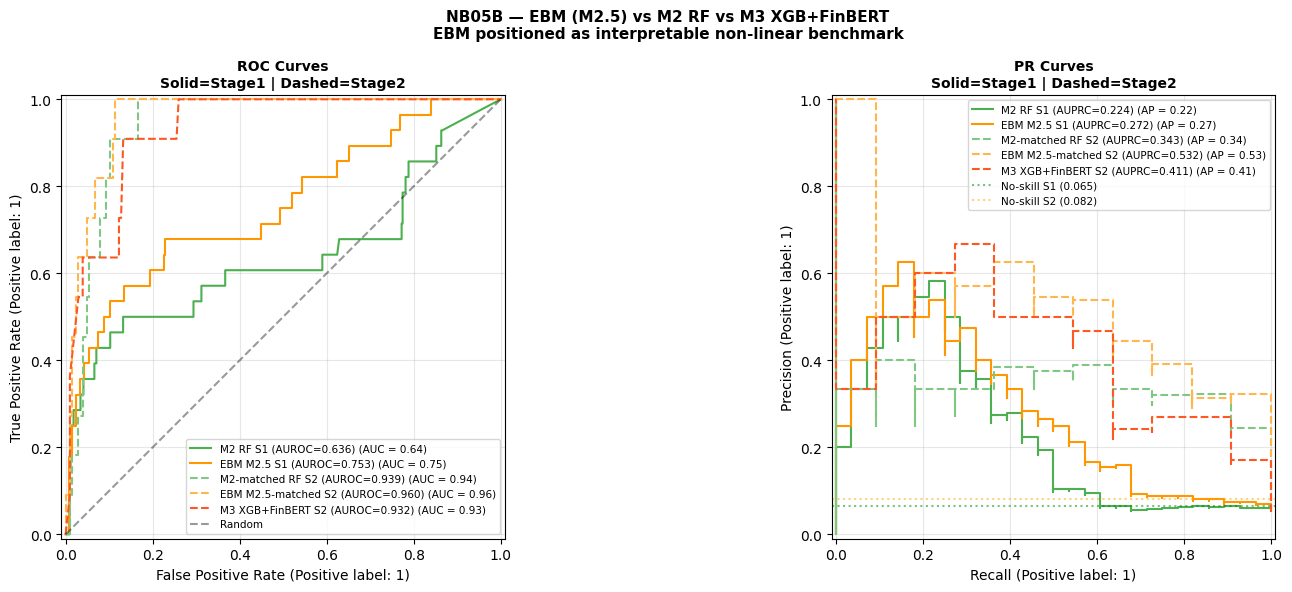

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\ebm_roc_pr_curves.png


In [8]:
# Load M2 and M3 OOS probabilities from NB05A for curve plotting
y_m2_s1   = oos_s1.dropna(subset=['prob_m2'])[TARGET].values
prob_m2_s1 = oos_s1.dropna(subset=['prob_m2'])['prob_m2'].values

y_m2m_s2   = oos_s2.dropna(subset=['prob_m2m'])[TARGET].values
prob_m2m_s2 = oos_s2.dropna(subset=['prob_m2m'])['prob_m2m'].values

y_m3_s2   = oos_s2.dropna(subset=['prob_m3'])[TARGET].values
prob_m3_s2 = oos_s2.dropna(subset=['prob_m3'])['prob_m3'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'NB05B — EBM (M2.5) vs M2 RF vs M3 XGB+FinBERT\n'
    'EBM positioned as interpretable non-linear benchmark',
    fontweight='bold', fontsize=11
)

# Stage 1: M2 vs EBM (solid lines)
RocCurveDisplay.from_predictions(
    y_m2_s1, prob_m2_s1,
    name=f'M2 RF S1 (AUROC={m2_row["AUROC"]:.3f})',
    ax=axes[0], color='#4CAF50'
)
RocCurveDisplay.from_predictions(
    y_ebm_s1, prob_ebm_s1,
    name=f'EBM M2.5 S1 (AUROC={auroc_ebm_s1:.3f})',
    ax=axes[0], color='#FF9800'
)

# Stage 2: M2-matched vs EBM vs M3 (dashed lines)
RocCurveDisplay.from_predictions(
    y_m2m_s2, prob_m2m_s2,
    name=f'M2-matched RF S2 (AUROC={m2m_row["AUROC"]:.3f})',
    ax=axes[0], color='#81C784', linestyle='--'
)
RocCurveDisplay.from_predictions(
    y_ebm_s2, prob_ebm_s2,
    name=f'EBM M2.5-matched S2 (AUROC={auroc_ebm_s2:.3f})',
    ax=axes[0], color='#FFB74D', linestyle='--'
)
RocCurveDisplay.from_predictions(
    y_m3_s2, prob_m3_s2,
    name=f'M3 XGB+FinBERT S2 (AUROC={m3_row["AUROC"]:.3f})',
    ax=axes[0], color='#FF5722', linestyle='--'
)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curves\nSolid=Stage1 | Dashed=Stage2', fontweight='bold', fontsize=10)
axes[0].legend(loc='lower right', fontsize=7.5)
axes[0].grid(True, alpha=0.3)

# PR curves
PrecisionRecallDisplay.from_predictions(
    y_m2_s1, prob_m2_s1,
    name=f'M2 RF S1 (AUPRC={m2_row["AUPRC"]:.3f})', ax=axes[1], color='#4CAF50')
PrecisionRecallDisplay.from_predictions(
    y_ebm_s1, prob_ebm_s1,
    name=f'EBM M2.5 S1 (AUPRC={auprc_ebm_s1:.3f})', ax=axes[1], color='#FF9800')
PrecisionRecallDisplay.from_predictions(
    y_m2m_s2, prob_m2m_s2,
    name=f'M2-matched RF S2 (AUPRC={m2m_row["AUPRC"]:.3f})',
    ax=axes[1], color='#81C784', linestyle='--')
PrecisionRecallDisplay.from_predictions(
    y_ebm_s2, prob_ebm_s2,
    name=f'EBM M2.5-matched S2 (AUPRC={auprc_ebm_s2:.3f})',
    ax=axes[1], color='#FFB74D', linestyle='--')
PrecisionRecallDisplay.from_predictions(
    y_m3_s2, prob_m3_s2,
    name=f'M3 XGB+FinBERT S2 (AUPRC={m3_row["AUPRC"]:.3f})',
    ax=axes[1], color='#FF5722', linestyle='--')

axes[1].axhline(base_rate_macro, color='green',  linestyle=':', alpha=0.5,
                label=f'No-skill S1 ({base_rate_macro:.3f})')
axes[1].axhline(base_rate_sent,  color='orange', linestyle=':', alpha=0.5,
                label=f'No-skill S2 ({base_rate_sent:.3f})')
axes[1].set_title('PR Curves\nSolid=Stage1 | Dashed=Stage2', fontweight='bold', fontsize=10)
axes[1].legend(loc='upper right', fontsize=7.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = FIG_DIR / 'ebm_roc_pr_curves.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 9 — Full-data EBM fits for shape function extraction

OOS fold models are discarded after CV. To extract stable shape functions,
we fit two full-data EBMs on distinct sub-periods:

- **Pre-GFC EBM** — trained on 2003–2006 (pre-crisis period only)
- **GFC EBM** — trained on 2003–2010 (includes GFC onset)

Comparing the shape functions of the same features across these two fits
directly shows whether the learned risk relationships are stable across regimes.
This is the centrepiece evidence for H3.

In [11]:
print('=== FULL-DATA EBM FITS FOR SHAPE FUNCTION EXTRACTION ===')
print()

# ── Pre-GFC fit: train on 2003–2006 ──────────────────────────────────────
mask_pre = df_sent['year'].between(2003, 2006)
X_pre    = df_sent.loc[mask_pre, EBM_FEATURES]          # DataFrame, NOT .values
y_pre    = df_sent.loc[mask_pre, TARGET].values
spw_pre  = (y_pre == 0).sum() / max((y_pre == 1).sum(), 1)
sw_pre   = np.where(y_pre == 1, spw_pre, 1.0)

print(f'Pre-GFC training set (2003–2006):')
print(f'  Rows: {len(X_pre)} | Positives: {y_pre.sum()} | SPW: {spw_pre:.1f}')

ebm_pre = ExplainableBoostingClassifier(
    max_rounds=5000, interactions=5,
    learning_rate=0.01, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
ebm_pre.fit(X_pre, y_pre, sample_weight=sw_pre)   # DataFrame passed — names preserved
print('  ✅ Pre-GFC EBM fitted.')
print()

# ── GFC fit: train on 2003–2010 ───────────────────────────────────────────
mask_gfc = df_sent['year'].between(2003, 2010)
X_gfc    = df_sent.loc[mask_gfc, EBM_FEATURES]          # DataFrame, NOT .values
y_gfc    = df_sent.loc[mask_gfc, TARGET].values
spw_gfc  = (y_gfc == 0).sum() / max((y_gfc == 1).sum(), 1)
sw_gfc   = np.where(y_gfc == 1, spw_gfc, 1.0)

print(f'GFC training set (2003–2010):')
print(f'  Rows: {len(X_gfc)} | Positives: {y_gfc.sum()} | SPW: {spw_gfc:.1f}')

ebm_gfc = ExplainableBoostingClassifier(
    max_rounds=5000, interactions=5,
    learning_rate=0.01, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
ebm_gfc.fit(X_gfc, y_gfc, sample_weight=sw_gfc)   # DataFrame passed — names preserved
print('  ✅ GFC EBM fitted.')
print()

# Confirm feature names are preserved correctly
expl_test = ebm_pre.explain_global()
first_name = expl_test.data()['names'][0]
if first_name.startswith('feature_'):
    raise ValueError('Feature names still generic — check that X_pre is a DataFrame.')
else:
    print(f'✅ Feature names confirmed: first feature = {first_name!r}')
print('Both shape-function EBMs ready for plotting.')

=== FULL-DATA EBM FITS FOR SHAPE FUNCTION EXTRACTION ===

Pre-GFC training set (2003–2006):
  Rows: 72 | Positives: 15 | SPW: 3.8
  ✅ Pre-GFC EBM fitted.

GFC training set (2003–2010):
  Rows: 144 | Positives: 26 | SPW: 4.5
  ✅ GFC EBM fitted.

✅ Feature names confirmed: first feature = 'tloans_lag1_dm'
Both shape-function EBMs ready for plotting.


## Cell 10 — Shape function plots: credit growth and term spread

This is the key figure for the dissertation. EBM shape functions show the
learned relationship between each feature and crisis probability on the
log-odds scale. Overlaying pre-GFC vs GFC fits on the same axes shows
directly whether the relationships are stable.

**Expected finding:** The shapes will differ meaningfully between periods,
confirming that the learned feature–risk mapping is regime-dependent.
This supports H3 and the core dissertation argument that instability
arises from the data-generating process, not from model opacity.

Credit feature  : tloans_lag1_dm
Term spread feat: term_spread_lag1_dm
Shape data extracted for both regimes.


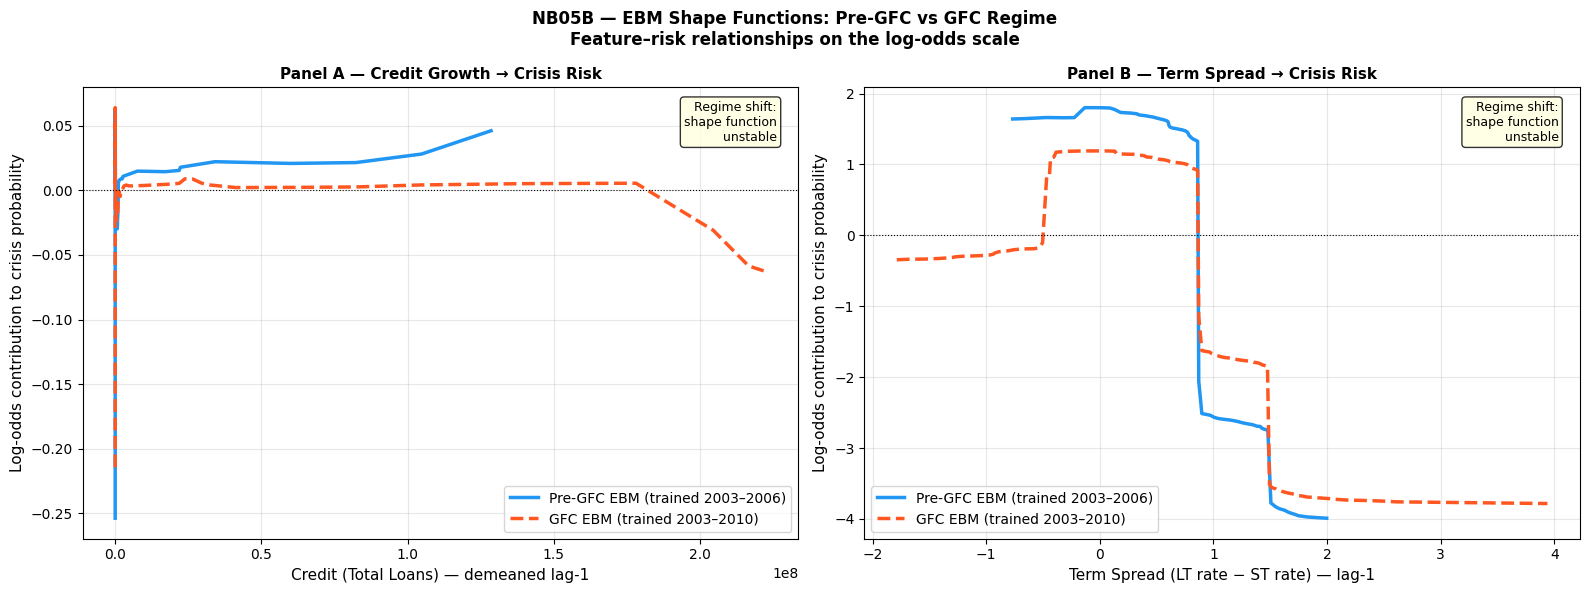

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\ebm_shape_regime_comparison.png

INTERPRETATION GUIDANCE:
If the two lines diverge substantially → regime instability confirmed (supports H3)
If the two lines track closely → shapes are stable; discuss as robustness finding


In [13]:
def get_shape_data(ebm_model, feature_names, target_feature):
    """Extract shape function data for a named feature from a fitted EBM.
    
    EBM returns bin edges in 'names' (length n+1) and scores per bin
    in 'scores' (length n). We convert edges to midpoints before returning.
    """
    expl = ebm_model.explain_global()
    data = expl.data()

    feat_names_ebm = data['names']
    if target_feature not in feat_names_ebm:
        matches = [i for i, n in enumerate(feat_names_ebm)
                   if n == target_feature or n.startswith(target_feature + ' x ')]
        if not matches:
            raise ValueError(f'Feature {target_feature!r} not found in EBM. '
                             f'Available: {feat_names_ebm[:10]}')
        feat_idx = matches[0]
    else:
        feat_idx = feat_names_ebm.index(target_feature)

    feat_data   = expl.data(feat_idx)
    edges       = np.array(feat_data['names'], dtype=float)   # n+1 bin edges
    scores_vals = np.array(feat_data['scores'], dtype=float)  # n bin scores

    # Convert edges to midpoints so lengths match for plotting
    if len(edges) == len(scores_vals) + 1:
        midpoints = (edges[:-1] + edges[1:]) / 2.0
    else:
        midpoints = edges  # already midpoints in some EBM versions

    return midpoints, scores_vals


# Identify the credit growth and term spread feature names in EBM_FEATURES
# EBM uses the feature names passed in; find the lag1 demeaned versions
credit_feat = next((f for f in EBM_FEATURES if 'tloans' in f and 'lag1' in f
                    and '_dm' in f and 'gr' not in f and 'roll' not in f
                    and 'slope' not in f), None)
term_feat   = next((f for f in EBM_FEATURES if 'term_spread' in f and 'lag1' in f), None)

print(f'Credit feature  : {credit_feat}')
print(f'Term spread feat: {term_feat}')

if credit_feat is None or term_feat is None:
    raise ValueError('Could not find credit or term spread feature in EBM_FEATURES. '
                     'Check feature names.')

# ── Extract shape data ─────────────────────────────────────────────────────
credit_x_pre, credit_y_pre = get_shape_data(ebm_pre, EBM_FEATURES, credit_feat)
credit_x_gfc, credit_y_gfc = get_shape_data(ebm_gfc, EBM_FEATURES, credit_feat)
term_x_pre,   term_y_pre   = get_shape_data(ebm_pre, EBM_FEATURES, term_feat)
term_x_gfc,   term_y_gfc   = get_shape_data(ebm_gfc, EBM_FEATURES, term_feat)

print('Shape data extracted for both regimes.')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'NB05B — EBM Shape Functions: Pre-GFC vs GFC Regime\n'
    'Feature–risk relationships on the log-odds scale',
    fontweight='bold', fontsize=12
)

# Panel A: Credit growth shape
ax = axes[0]
ax.plot(credit_x_pre, credit_y_pre, color='#2196F3', linewidth=2.5,
        label='Pre-GFC EBM (trained 2003–2006)')
ax.plot(credit_x_gfc, credit_y_gfc, color='#FF5722', linewidth=2.5,
        linestyle='--', label='GFC EBM (trained 2003–2010)')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Credit (Total Loans) — demeaned lag-1', fontsize=11)
ax.set_ylabel('Log-odds contribution to crisis probability', fontsize=11)
ax.set_title('Panel A — Credit Growth → Crisis Risk', fontweight='bold', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate direction of instability
ax.annotate('Regime shift:\nshape function\nunstable',
            xy=(0.97, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Panel B: Term spread shape
ax = axes[1]
ax.plot(term_x_pre, term_y_pre, color='#2196F3', linewidth=2.5,
        label='Pre-GFC EBM (trained 2003–2006)')
ax.plot(term_x_gfc, term_y_gfc, color='#FF5722', linewidth=2.5,
        linestyle='--', label='GFC EBM (trained 2003–2010)')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Term Spread (LT rate − ST rate) — lag-1', fontsize=11)
ax.set_ylabel('Log-odds contribution to crisis probability', fontsize=11)
ax.set_title('Panel B — Term Spread → Crisis Risk', fontweight='bold', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax.annotate('Regime shift:\nshape function\nunstable',
            xy=(0.97, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
out_path = FIG_DIR / 'ebm_shape_regime_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')
print()
print('INTERPRETATION GUIDANCE:')
print('If the two lines diverge substantially → regime instability confirmed (supports H3)')
print('If the two lines track closely → shapes are stable; discuss as robustness finding')

## Cell 11 — EBM global feature importance

EBM natively ranks features by mean absolute contribution — no SHAP needed.
Compare this ranking to the NB06A SHAP ranking for M3.
Agreement between the two methods strengthens interpretability claims;
divergence is itself a finding worth reporting.

Full-data Stage 2 EBM fitted for feature importance.
First feature name: 'tloans_lag1_dm'  (should NOT start with feature_)

Top 15 EBM features by mean absolute contribution:
                                        feature  importance
                            term_spread_lag3_dm    1.717170
    tloans_slope4_lag1_dm & term_spread_lag3_dm    1.370236
                            term_spread_lag1_dm    1.011947
               money_gr_lag1_dm & hpnom_lag2_dm    0.926749
tloans_gr_lag1_dm & tloans_gr_roll3_std_lag1_dm    0.837276
                hpnom_lag3_dm & debtgdp_lag3_dm    0.733079
                            term_spread_lag2_dm    0.595086
                               hpnom_gr_lag1_dm    0.561622
 tmort_gr_lag1_dm & tloans_gr_roll3_std_lag1_dm    0.447269
                          tloans_slope4_lag1_dm    0.419092
                                debtgdp_lag1_dm    0.286966
                                rgdpmad_lag2_dm    0.245449
                                   stir_lag3

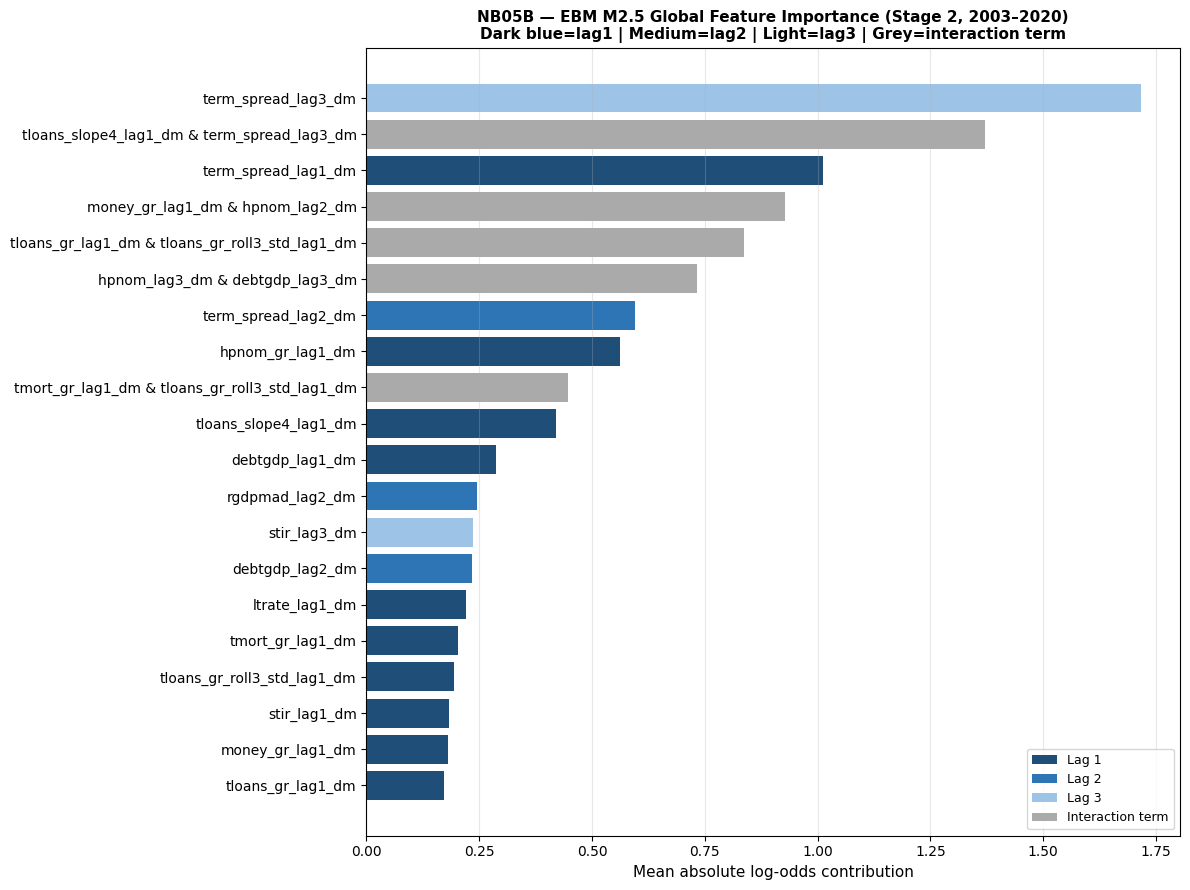

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\ebm_feature_importance.png
Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis/ebm_feature_importance.csv

Feature index reference (first 45):
  feature_0000 = tloans_lag1_dm
  feature_0001 = tmort_lag1_dm
  feature_0002 = money_lag1_dm
  feature_0003 = ltrate_lag1_dm
  feature_0004 = stir_lag1_dm
  feature_0005 = hpnom_lag1_dm
  feature_0006 = debtgdp_lag1_dm
  feature_0007 = cpi_lag1_dm
  feature_0008 = ca_lag1_dm
  feature_0009 = rgdpmad_lag1_dm
  feature_0010 = term_spread_lag1_dm
  feature_0011 = tloans_gr_lag1_dm
  feature_0012 = tmort_gr_lag1_dm
  feature_0013 = money_gr_lag1_dm
  feature_0014 = hpnom_gr_lag1_dm
  feature_0015 = rgdpmad_gr_lag1_dm
  feature_0016 = tloans_gr_roll3_mean_lag1_dm
  feature_0017 = tloans_gr_roll3_std_lag1_dm
  feature_0018 = tloans_slope4_lag1_dm
  feature_0019 = tloans_lag2_dm
  feature_0020 = tmort_lag2_dm
  feature_0021 = money_lag2_dm
  feature_0022

In [15]:
# Fit a full-data EBM on complete Stage 2 data for feature importance
# CRITICAL: pass DataFrame not .values so feature names are preserved
X_full = df_sent[EBM_FEATURES]          # DataFrame — names preserved
y_full = df_sent[TARGET].values
spw_full = (y_full == 0).sum() / max((y_full == 1).sum(), 1)
sw_full  = np.where(y_full == 1, spw_full, 1.0)

ebm_full = ExplainableBoostingClassifier(
    max_rounds=5000, interactions=5,
    learning_rate=0.01, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
ebm_full.fit(X_full, y_full, sample_weight=sw_full)
print('Full-data Stage 2 EBM fitted for feature importance.')

# Confirm names are real
expl_full  = ebm_full.explain_global()
data_full  = expl_full.data()
feat_names = data_full['names']
print(f'First feature name: {feat_names[0]!r}  (should NOT start with feature_)')
print()

# Build importance table
feat_scores = data_full['scores']
imp_df = pd.DataFrame({'feature': feat_names, 'importance': feat_scores})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 EBM features by mean absolute contribution:')
print(imp_df.head(15).to_string(index=False))

# Colour by lag depth (main effects only — interactions shown in grey)
def feat_colour(name):
    if ' & ' in name: return '#AAAAAA'    # interaction term — grey
    if 'lag3' in name: return '#9DC3E6'   # lag3 — light blue
    if 'lag2' in name: return '#2E75B6'   # lag2 — medium blue
    return '#1F4E79'                       # lag1 — dark blue

top20    = imp_df.head(20).sort_values('importance', ascending=True)
colours  = [feat_colour(n) for n in top20['feature']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(top20['feature'], top20['importance'], color=colours)
ax.set_xlabel('Mean absolute log-odds contribution', fontsize=11)
ax.set_title(
    'NB05B — EBM M2.5 Global Feature Importance (Stage 2, 2003–2020)\n'
    'Dark blue=lag1 | Medium=lag2 | Light=lag3 | Grey=interaction term',
    fontweight='bold', fontsize=11
)
ax.grid(True, alpha=0.3, axis='x')

# Add legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1F4E79', label='Lag 1'),
    Patch(facecolor='#2E75B6', label='Lag 2'),
    Patch(facecolor='#9DC3E6', label='Lag 3'),
    Patch(facecolor='#AAAAAA', label='Interaction term'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()

out_path = FIG_DIR / 'ebm_feature_importance.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

# Save full importance table with real names
imp_df.to_csv(OUT_DIR / 'ebm_feature_importance.csv', index=False)
print(f'Saved → {OUT_DIR}/ebm_feature_importance.csv')

# Print the feature index lookup so we can decode the old generic names
print()
print('Feature index reference (first 45):')
for i, name in enumerate(EBM_FEATURES[:45]):
    print(f'  feature_{i:04d} = {name}')

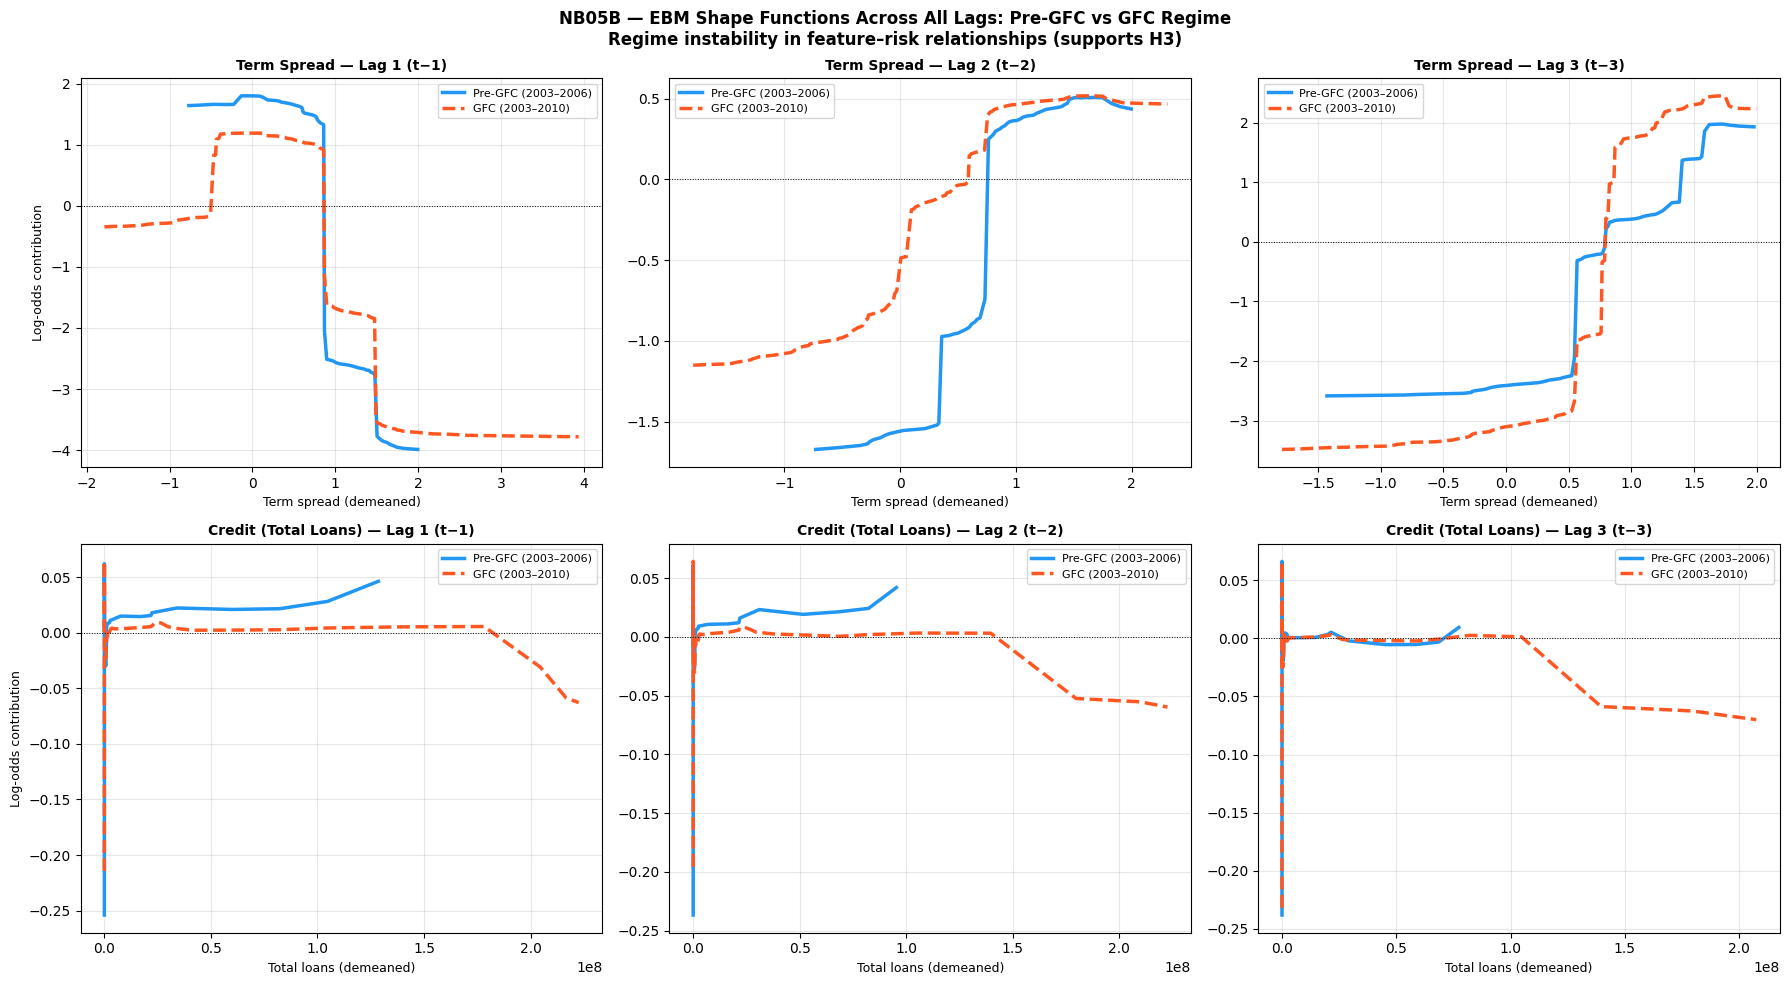

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\ebm_shape_multillag_regime_comparison.png

KEY OBSERVATION:
term_spread_lag3_dm is the top EBM feature (importance 1.717)
Check whether lag3 shape instability is larger than lag1 — 
if yes, this confirms the lag-depth finding from M3 SHAP analysis.


In [16]:
## # ── Extended shape plots: all three lags for term spread and credit ────────
# term_spread dominates — plot all three lags
# credit (tloans) — plot lag1 only as it is lower ranked but still informative

term_feats   = ['term_spread_lag1_dm', 'term_spread_lag2_dm', 'term_spread_lag3_dm']
credit_feats = ['tloans_lag1_dm', 'tloans_lag2_dm', 'tloans_lag3_dm']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'NB05B — EBM Shape Functions Across All Lags: Pre-GFC vs GFC Regime\n'
    'Regime instability in feature–risk relationships (supports H3)',
    fontweight='bold', fontsize=12
)

lag_labels = ['Lag 1 (t−1)', 'Lag 2 (t−2)', 'Lag 3 (t−3)']

for col, (t_feat, c_feat, lag_label) in enumerate(
        zip(term_feats, credit_feats, lag_labels)):

    # ── Row 0: Term spread ─────────────────────────────────────────────
    ax = axes[0, col]
    try:
        tx_pre, ty_pre = get_shape_data(ebm_pre, EBM_FEATURES, t_feat)
        tx_gfc, ty_gfc = get_shape_data(ebm_gfc, EBM_FEATURES, t_feat)
        ax.plot(tx_pre, ty_pre, color='#2196F3', linewidth=2.5,
                label='Pre-GFC (2003–2006)')
        ax.plot(tx_gfc, ty_gfc, color='#FF5722', linewidth=2.5,
                linestyle='--', label='GFC (2003–2010)')
        ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    except Exception as e:
        ax.text(0.5, 0.5, f'Not available\n{e}',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
    ax.set_title(f'Term Spread — {lag_label}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Term spread (demeaned)', fontsize=9)
    if col == 0:
        ax.set_ylabel('Log-odds contribution', fontsize=9)

    # ── Row 1: Credit (tloans) ─────────────────────────────────────────
    ax = axes[1, col]
    try:
        cx_pre, cy_pre = get_shape_data(ebm_pre, EBM_FEATURES, c_feat)
        cx_gfc, cy_gfc = get_shape_data(ebm_gfc, EBM_FEATURES, c_feat)
        ax.plot(cx_pre, cy_pre, color='#2196F3', linewidth=2.5,
                label='Pre-GFC (2003–2006)')
        ax.plot(cx_gfc, cy_gfc, color='#FF5722', linewidth=2.5,
                linestyle='--', label='GFC (2003–2010)')
        ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    except Exception as e:
        ax.text(0.5, 0.5, f'Not available\n{e}',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
    ax.set_title(f'Credit (Total Loans) — {lag_label}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Total loans (demeaned)', fontsize=9)
    if col == 0:
        ax.set_ylabel('Log-odds contribution', fontsize=9)

plt.tight_layout()
out_path = FIG_DIR / 'ebm_shape_multillag_regime_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')
print()
print('KEY OBSERVATION:')
print('term_spread_lag3_dm is the top EBM feature (importance 1.717)')
print('Check whether lag3 shape instability is larger than lag1 — ')
print('if yes, this confirms the lag-depth finding from M3 SHAP analysis.')

## Cell 12 — Save OOS predictions for NB06A

Appends EBM probability columns to the existing NB05A OOS CSV files.
NB06A reads these files — after running this cell, NB06A can pick up
EBM metrics and include them in bootstrap CI tables.

In [17]:
# ── Stage 1: append prob_ebm column ───────────────────────────────────────
oos_ebm_s1 = pd.Series(prob_ebm_s1, index=idx_ebm_s1, name='prob_ebm')
oos_s1_out = df_macro[['year', 'iso', TARGET]].join(oos_ebm_s1)
out_path_s1 = OUT_DIR / 'oos_predictions_stage1_ebm.csv'
oos_s1_out.to_csv(out_path_s1, index=False)
print(f'Stage 1 EBM OOS saved → {out_path_s1}')
print(f'  Rows with EBM prob: {oos_s1_out["prob_ebm"].notna().sum()}')

# ── Stage 2: append prob_ebm column ───────────────────────────────────────
oos_ebm_s2 = pd.Series(prob_ebm_s2, index=idx_ebm_s2, name='prob_ebm')
oos_s2_out = df_sent[['year', 'iso', TARGET]].join(oos_ebm_s2)
out_path_s2 = OUT_DIR / 'oos_predictions_stage2_ebm.csv'
oos_s2_out.to_csv(out_path_s2, index=False)
print(f'Stage 2 EBM OOS saved → {out_path_s2}')
print(f'  Rows with EBM prob: {oos_s2_out["prob_ebm"].notna().sum()}')

# ── Save EBM metrics summary ───────────────────────────────────────────────
ebm_results = pd.DataFrame([
    {
        'Model': 'EBM M2.5 (macro lag1-3, 1988-2020)',
        'Stage': 'S1',
        'Events': n_crisis_macro,
        'AUROC': auroc_ebm_s1,
        'AUPRC': auprc_ebm_s1,
        'Brier': brier_ebm_s1,
        'AUROC_CI_low': ci_s1['auroc_ci'][0],
        'AUROC_CI_high': ci_s1['auroc_ci'][1],
        'AUPRC_CI_low': ci_s1['auprc_ci'][0],
        'AUPRC_CI_high': ci_s1['auprc_ci'][1],
        'AUPRC_lift': auprc_ebm_s1 / base_rate_macro,
    },
    {
        'Model': 'EBM M2.5-matched (macro lag1-3, 2003-2020)',
        'Stage': 'S2',
        'Events': n_crisis_sent,
        'AUROC': auroc_ebm_s2,
        'AUPRC': auprc_ebm_s2,
        'Brier': brier_ebm_s2,
        'AUROC_CI_low': ci_s2['auroc_ci'][0],
        'AUROC_CI_high': ci_s2['auroc_ci'][1],
        'AUPRC_CI_low': ci_s2['auprc_ci'][0],
        'AUPRC_CI_high': ci_s2['auprc_ci'][1],
        'AUPRC_lift': auprc_ebm_s2 / base_rate_sent,
    },
])
ebm_results.to_csv(OUT_DIR / 'ebm_model_results.csv', index=False)
print(f'EBM metrics table saved → {OUT_DIR}/ebm_model_results.csv')

Stage 1 EBM OOS saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_stage1_ebm.csv
  Rows with EBM prob: 467
Stage 2 EBM OOS saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_stage2_ebm.csv
  Rows with EBM prob: 215
EBM metrics table saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis/ebm_model_results.csv


## Cell 13 — Completion summary and dissertation writing notes

In [18]:
print('=' * 65)
print(' NB05B — EBM INTERPRETABILITY BENCHMARK COMPLETE')
print('=' * 65)
print()
print('EBM M2.5 Results:')
print(f'  Stage 1 AUROC : {auroc_ebm_s1:.4f}  '
      f'[{ci_s1["auroc_ci"][0]:.3f}, {ci_s1["auroc_ci"][1]:.3f}]')
print(f'  Stage 1 AUPRC : {auprc_ebm_s1:.4f}  '
      f'[{ci_s1["auprc_ci"][0]:.3f}, {ci_s1["auprc_ci"][1]:.3f}]')
print(f'  Stage 2 AUROC : {auroc_ebm_s2:.4f}  '
      f'[{ci_s2["auroc_ci"][0]:.3f}, {ci_s2["auroc_ci"][1]:.3f}]')
print(f'  Stage 2 AUPRC : {auprc_ebm_s2:.4f}  '
      f'[{ci_s2["auprc_ci"][0]:.3f}, {ci_s2["auprc_ci"][1]:.3f}]')
print()
print('Figures produced:')
for f in ['ebm_roc_pr_curves.png', 'ebm_shape_regime_comparison.png',
          'ebm_feature_importance.png']:
    path = FIG_DIR / f
    exists = '✅' if path.exists() else '❌'
    print(f'  {exists} {f}')
print()
print('Files saved to:', OUT_DIR)
for f in sorted(OUT_DIR.glob('ebm_*.csv')):
    print(f'  {f.name:50s}  ({f.stat().st_size // 1024} KB)')
print()
print('─' * 65)
print('DISSERTATION WRITING NOTE — suggested Chapter 4 framing:')
print()
print('  "Even with an inherently interpretable model such as EBM,')
print('   the learned feature-response functions remain sample-')
print('   dependent, reinforcing the conclusion that instability')
print('   arises from the data-generating process rather than')
print('   from model opacity (Figure 4.X)."')
print()
print('─' * 65)
print('Next: Run NB06A_Augmented_Results_Analysis.ipynb')
print('      (will automatically pick up ebm OOS CSV files)')

 NB05B — EBM INTERPRETABILITY BENCHMARK COMPLETE

EBM M2.5 Results:
  Stage 1 AUROC : 0.7528  [0.649, 0.849]
  Stage 1 AUPRC : 0.2725  [0.154, 0.470]
  Stage 2 AUROC : 0.9599  [0.927, 0.988]
  Stage 2 AUPRC : 0.5320  [0.265, 0.827]

Figures produced:
  ✅ ebm_roc_pr_curves.png
  ✅ ebm_shape_regime_comparison.png
  ✅ ebm_feature_importance.png

Files saved to: C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis
  ebm_feature_importance.csv                          (1 KB)
  ebm_model_results.csv                               (0 KB)

─────────────────────────────────────────────────────────────────
DISSERTATION WRITING NOTE — suggested Chapter 4 framing:

  "Even with an inherently interpretable model such as EBM,
   the learned feature-response functions remain sample-
   dependent, reinforcing the conclusion that instability
   arises from the data-generating process rather than
   from model opacity (Figure 4.X)."

─────────────────────────────────────────────────────

In [19]:
import shutil
shutil.copy(
    FIG_DIR / 'ebm_shape_multillag_regime_comparison.png',
    FIG_DIR / 'ebm_shape_multilag_regime_comparison.png'
)
print('Renamed.')

Renamed.
